In [1]:
# ============================================================
# CELL 1: Environment Setup & Install Required Packages
# ============================================================

# Install required packages (run this cell first)
import sys
import subprocess

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# List of packages to install
packages = [
    "tensorflow",
    "numpy",
    "pandas",
    "opencv-python",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tqdm",
    "jupyter"
]

print("Installing required packages...")
for package in packages:
    try:
        __import__(package.replace("-", "_").split("=")[0])
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)

print("\nAll packages installed successfully!")

# Now import all required modules
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Verify GPU
print(f"\nTensorFlow version: {tf.__version__}")
print("GPU available:", tf.config.list_physical_devices('GPU'))

Installing required packages...
✓ tensorflow already installed
✓ numpy already installed
✓ pandas already installed
Installing opencv-python...
✓ matplotlib already installed
✓ seaborn already installed
Installing scikit-learn...
✓ tqdm already installed
✓ jupyter already installed

All packages installed successfully!

TensorFlow version: 2.20.0
GPU available: []


In [2]:
# ============================================================
# CELL 2: Set Kaggle Credentials (Optional)
# ============================================================
os.environ['KAGGLE_USERNAME'] = "okechukwu88"
os.environ['KAGGLE_KEY'] = "YKGAT_dfb8307c167c3e8bdd2701364d3a9a59"

In [3]:
# ============================================================
# CELL 3: Set Dataset Path for Local Machine
# ============================================================
import os

# Set the path to your extracted dataset folder on your local machine
# Update this path to where you have extracted the ExpW dataset
DATA_DIR = r"C:\Users\2550902\Downloads\extracted"  # <-- CHANGE THIS TO YOUR ACTUAL PATH

# Verify the dataset exists
IMAGE_DIR = os.path.join(DATA_DIR, 'image')
LABEL_FILE = os.path.join(DATA_DIR, 'label', 'label.lst')

if not os.path.exists(IMAGE_DIR):
    print(f"WARNING: Image directory not found at {IMAGE_DIR}")
    print("Please update DATA_DIR to the correct path where your ExpW dataset is extracted.")
    print("\nExpected folder structure:")
    print("  your_dataset_folder/")
    print("    ├── image/           (contains all .jpg images)")
    print("    └── label/            (contains label.lst)")
else:
    print(f"Dataset found at: {DATA_DIR}")
    print(f"Image directory: {IMAGE_DIR}")
    print(f"Label file: {LABEL_FILE}")

# Save the dataset root path for later cells
with open('dataset_root.txt', 'w') as f:
    f.write(DATA_DIR)

print(f"\nDataset path saved to dataset_root.txt")

Dataset found at: C:\Users\2550902\Downloads\extracted
Image directory: C:\Users\2550902\Downloads\extracted\image
Label file: C:\Users\2550902\Downloads\extracted\label\label.lst

Dataset path saved to dataset_root.txt


In [4]:
# ============================================================
# CELL 4: Set Constants and Dataset Paths
# ============================================================
# Read the dataset root from the file saved in Cell 3
with open('dataset_root.txt', 'r') as f:
    DATA_DIR = f.read().strip()

# Set image directory - using 'image' folder (your extracted structure)
IMAGE_DIR = os.path.join(DATA_DIR, 'image')
LABEL_FILE = os.path.join(DATA_DIR, 'label', 'label.lst')

# Verify paths exist
print(f"Dataset root: {DATA_DIR}")
print(f"Image directory exists: {os.path.exists(IMAGE_DIR)}")
print(f"Label file exists: {os.path.exists(LABEL_FILE)}")

IMG_SIZE = 48
BATCH_SIZE = 64
EPOCHS = 50
INITIAL_LR = 0.001

# ------------------------------------------------------------
# FLEXIBLE CLASS MAPPING
# Choose one of the following configurations by setting CLASS_CONFIG.
# ------------------------------------------------------------
CLASS_CONFIG = '4'   # Options: '4', '7', '8'

if CLASS_CONFIG == '7':
    # Original 7-class mapping
    EMOTION_TO_INT = {
        'angry': 0, 'mad': 0, 'fighting': 0, 'annoyed': 0,
        'disgust': 1,
        'fear': 2, 'scared': 2, 'awe': 2,
        'happy': 3, 'joy': 3,
        'sad': 4, 'crying': 4, 'unhappy': 4,
        'surprise': 5, 'shocked': 5, 'astound': 5,
        'neutral': 6, 'serious': 6, 'calm': 6,
    }
    EMOTION_LABELS = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',
                      4:'Sad',5:'Surprise',6:'Neutral'}

elif CLASS_CONFIG == '4':
    # 4-class grouping (Happy, Sad, Angry, Neutral)
    EMOTION_TO_INT = {
        'angry': 0, 'mad': 0, 'fighting': 0, 'annoyed': 0,
        'happy': 1, 'joy': 1,
        'sad': 2, 'crying': 2, 'unhappy': 2,
        'neutral': 3, 'serious': 3, 'calm': 3,
        # Other emotions can be mapped to a default or ignored
        'disgust': 0,   # optionally map disgust to angry
        'fear': 2, 'scared': 2, 'awe': 2,
        'surprise': 1, 'shocked': 1, 'astound': 1,
    }
    EMOTION_LABELS = {0:'Angry',1:'Happy',2:'Sad',3:'Neutral'}

elif CLASS_CONFIG == '8':
    # 8-class mapping (example – split some categories)
    EMOTION_TO_INT = {
        'angry': 0, 'mad': 0, 'fighting': 0, 'annoyed': 0,
        'disgust': 1,
        'fear': 2, 'scared': 2, 'awe': 2,
        'happy': 3, 'joy': 3,
        'sad': 4, 'crying': 4, 'unhappy': 4,
        'surprise': 5, 'shocked': 5, 'astound': 5,
        'neutral': 6, 'serious': 6, 'calm': 6,
        'contempt': 7,   # add an 8th class if present in dataset
    }
    EMOTION_LABELS = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',
                      4:'Sad',5:'Surprise',6:'Neutral',7:'Contempt'}
else:
    raise ValueError("CLASS_CONFIG must be one of '4', '7', '8'")

NUM_CLASSES = len(set(EMOTION_TO_INT.values()))
print(f"Using {NUM_CLASSES} classes: {EMOTION_LABELS}")

# ------------------------------------------------------------
# PREPROCESSING FLAGS
# ------------------------------------------------------------
APPLY_HIST_EQ = True      # Apply histogram equalization
APPLY_GAUSSIAN_BLUR = True   # Apply Gaussian blur (kernel 3x3)

# ------------------------------------------------------------
# FACE REGIONS FOR EXPLANATIONS (unchanged)
# ------------------------------------------------------------
FACE_REGIONS = {
    'mouth': (0.60, 0.85, 0.30, 0.70),
    'eyes': (0.25, 0.45, 0.20, 0.80),
    'eyebrows': (0.15, 0.30, 0.20, 0.80),
    'nose': (0.40, 0.60, 0.40, 0.60),
    'forehead': (0.05, 0.20, 0.20, 0.80),
    'chin': (0.80, 0.95, 0.35, 0.65)
}

FRIENDLY_EXPLANATIONS = {
    ('Happy', 'mouth'): "their MOUTH is smiling 😊",
    ('Happy', 'eyes'): "their EYES are smiling 😊",
    ('Happy', 'cheeks'): "their CHEEKS are raised 😊",
    ('Sad', 'mouth'): "their MOUTH is turned down 😢",
    ('Sad', 'eyes'): "their EYES look droopy 😢",
    ('Sad', 'eyebrows'): "their EYEBROWS are pulled up in the middle 😢",
    ('Angry', 'eyebrows'): "their EYEBROWS are pulled down and together 😠",
    ('Angry', 'mouth'): "their MOUTH is pressed tight 😠",
    ('Angry', 'eyes'): "their EYES are staring hard 😠",
    ('Fear', 'eyes'): "their EYES are wide open 😨",
    ('Fear', 'eyebrows'): "their EYEBROWS are raised up 😨",
    ('Fear', 'mouth'): "their MOUTH is open in an O 😨",
    ('Surprise', 'eyes'): "their EYES are round like circles 😮",
    ('Surprise', 'eyebrows'): "their EYEBROWS are curved high 😮",
    ('Surprise', 'mouth'): "their MOUTH is open like an O 😮",
    ('Disgust', 'nose'): "their NOSE is wrinkled 🤢",
    ('Disgust', 'upper_lip'): "their UPPER LIP is raised 🤢",
    ('Disgust', 'eyes'): "their EYES are squinting 🤢",
    ('Neutral', 'mouth'): "their MOUTH is a straight line 😐",
    ('Neutral', 'eyes'): "their EYES are calm 😐",
    ('Neutral', 'face'): "their FACE is relaxed 😐"
}

Dataset root: C:\Users\2550902\Downloads\extracted
Image directory exists: True
Label file exists: False
Using 4 classes: {0: 'Angry', 1: 'Happy', 2: 'Sad', 3: 'Neutral'}


Loading ExpW Dataset from filenames...
Loading images from: C:\Users\2550902\Downloads\extracted\image


Loading ExpW images: 100%|██████████| 106962/106962 [03:58<00:00, 447.93it/s]  


Loaded 59442 images. Skipped 47520 images.

Dataset split complete:
  Train: 35665 samples
  Validation: 11888 samples
  Test: 11889 samples


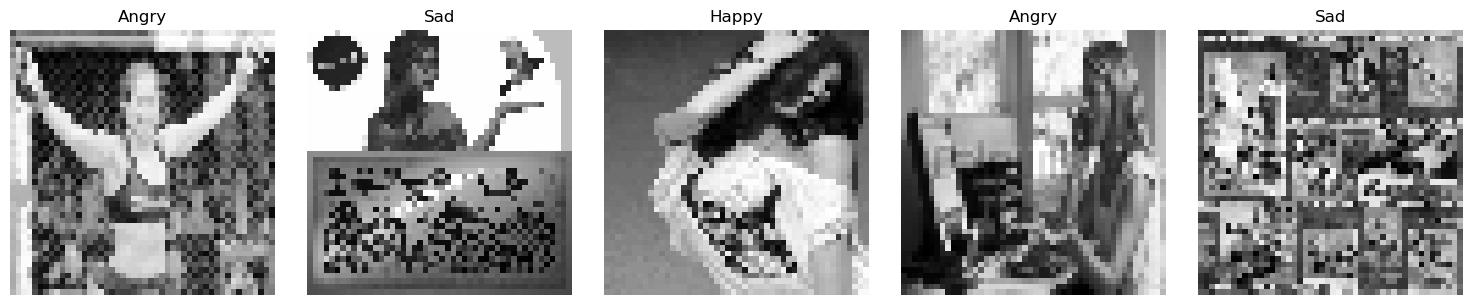

In [5]:
# ============================================================
# CELL 5: Load the ExpW Dataset from Filenames
#         with image cleaning and optional preprocessing
# ============================================================
import os
import glob
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def preprocess_image(img, apply_eq=True, apply_blur=True):
    """Apply optional preprocessing steps to a grayscale image."""
    if apply_eq:
        img = cv2.equalizeHist(img)
    if apply_blur:
        img = cv2.GaussianBlur(img, (3,3), 0)
    return img

def load_expw_data_from_filenames(image_dir, emotion_map,
                                   img_size=(48,48),
                                   apply_eq=False,
                                   apply_blur=False,
                                   max_samples=None):
    """
    Loads images, skips corrupt files, and applies preprocessing.
    Expects filenames like '<emotion>_..._<number>.jpg'.
    """
    images = []
    labels = []
    skipped = 0

    image_paths = glob.glob(os.path.join(image_dir, "*.jpg"))
    if max_samples:
        image_paths = image_paths[:max_samples]

    print(f"Loading images from: {image_dir}")
    for img_path in tqdm(image_paths, desc="Loading ExpW images"):
        fname = os.path.basename(img_path)
        parts = fname.split('_')
        if not parts:
            skipped += 1
            continue
        emotion_str = parts[0].lower()
        if emotion_str not in emotion_map:
            skipped += 1
            continue
        label = emotion_map[emotion_str]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            skipped += 1
            continue

        # Preprocess
        img = preprocess_image(img, apply_eq=apply_eq, apply_blur=apply_blur)

        img_resized = cv2.resize(img, img_size)
        img_normalized = img_resized.astype('float32') / 255.0

        images.append(img_normalized)
        labels.append(label)

    if not images:
        raise RuntimeError("No images loaded. Check image directory and emotion mapping.")

    X = np.array(images).reshape(-1, img_size[0], img_size[1], 1)
    y = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)

    print(f"Loaded {len(X)} images. Skipped {skipped} images.")
    return X, y

print("="*50)
print("Loading ExpW Dataset from filenames...")

X, y = load_expw_data_from_filenames(
    IMAGE_DIR, EMOTION_TO_INT,
    apply_eq=APPLY_HIST_EQ,
    apply_blur=APPLY_GAUSSIAN_BLUR
)

# Split into train/validation/test (60-20-20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nDataset split complete:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

# Quick sanity check: visualize some samples
def plot_sample_images(X, y, labels_map, num_samples=5):
    plt.figure(figsize=(15, 3))
    y_int = np.argmax(y, axis=1)
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(X[i].squeeze(), cmap='gray')
        if isinstance(labels_map, dict):
            title = labels_map.get(y_int[i], str(y_int[i]))
        else:
            title = labels_map[y_int[i]]
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(X_train, y_train, EMOTION_LABELS)

In [6]:
# ============================================================
# CELL 6: Create TensorFlow Datasets with Augmentation
# ============================================================
def create_tf_dataset(X, y, batch_size, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
        augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.1),
        ])
        dataset = dataset.map(lambda x, y: (augmentation(x, training=True), y),
                              num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(buffer_size=1000)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_tf_dataset(X_train, y_train, BATCH_SIZE, training=True)
val_ds = create_tf_dataset(X_val, y_val, BATCH_SIZE)
test_ds = create_tf_dataset(X_test, y_test, BATCH_SIZE)

In [9]:
# ============================================================
# CELL 7: Build Multiple CNN Models
# ============================================================
from tensorflow.keras import layers, Model

def build_model_v1(input_shape=(48,48,1), num_classes=7):
    """Original model from the notebook."""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name="ExpW_CNN_v1")
    return model

def build_model_v2(input_shape=(48,48,1), num_classes=7):
    """Deeper model with more filters."""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name="ExpW_CNN_v2")
    return model

def build_model_v3(input_shape=(48,48,1), num_classes=7):
    """Simpler model with fewer layers."""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name="ExpW_CNN_v3")
    return model

def build_model_v4(input_shape=(48,48,1), num_classes=7):
    """Model with residual connections."""
    inputs = layers.Input(shape=input_shape)

    # First block
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    shortcut = layers.Conv2D(32, 1, padding='same')(inputs)
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Second block
    shortcut = layers.Conv2D(64, 1, padding='same')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Third block
    shortcut = layers.Conv2D(128, 1, padding='same')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name="ExpW_CNN_v4")
    return model

# List of model builders
MODEL_BUILDERS = [
    build_model_v1,
    build_model_v2,
    build_model_v3,
    build_model_v4
]

In [10]:
# ============================================================
# CELL 8: Compile the Models
# ============================================================
models = []
for builder in MODEL_BUILDERS:
    model = builder(num_classes=NUM_CLASSES)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    models.append(model)
    model.summary()

Model: "ExpW_CNN_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,252 (1.16 MB)

 Trainable params: 304,356 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

...

Model: "ExpW_CNN_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 48, 48,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 48, 48,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 48, 48,    │         64 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 24, 24,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 24, 24,    │          0 │ max_pooling2d_10… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 24, 24,    │     18,496 │ dropout_13[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 24, 24,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 24, 24,    │      2,112 │ dropout_13[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 24,    │          0 │ add_1[0][0]     

 Total params: 315,748 (1.20 MB)

 Trainable params: 314,852 (1.20 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
# ============================================================
# CELL 9: Train the Models
# ============================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                     monitor='val_accuracy', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7,
                                         monitor='val_loss'),
]

histories = []
for i, model in enumerate(models):
    print(f"\nTraining model {i+1}: {model.name}")
    # Create a unique checkpoint for each model
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f'./best_expw_model_{i}.keras',
        save_best_only=True,
        monitor='val_accuracy', mode='max'
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[checkpoint] + callbacks,
        verbose=1
    )
    histories.append(history)


Training model 1: ExpW_CNN_v1
Epoch 1/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 60s 99ms/step - accuracy: 0.4250 - loss: 1.0916 - precision: 0.4597 - recall: 0.0963 - val_accuracy: 0.4452 - val_loss: 1.0554 - val_precision: 0.5238 - val_recall: 0.0222 - learning_rate: 0.0010
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 62s 110ms/step - accuracy: 0.4378 - loss: 1.0597 - precision: 0.5293 - recall: 0.0652 - val_accuracy: 0.4245 - val_loss: 1.0584 - val_precision: 0.5086 - val_recall: 0.1523 - learning_rate: 0.0010
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 61s 109ms/step - accuracy: 0.4418 - loss: 1.0576 - precision: 0.5360 - recall: 0.0665 - val_accuracy: 0.4372 - val_loss: 1.0507 - val_precision: 0.5685 - val_recall: 0.0820 - learning_rate: 0.0010
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 62s 110ms/step - accuracy: 0.4429 - loss: 1.0554 - precision: 0.5413 - recall: 0.0682 - val_accuracy: 0.4405 - val_loss: 1.0613 - val_precision: 0.5792 - val_recall: 0.0384 - learning_rate: 0.0010
Epoch 5/50
558/558 ━━━


MODEL 1: ExpW_CNN_v1


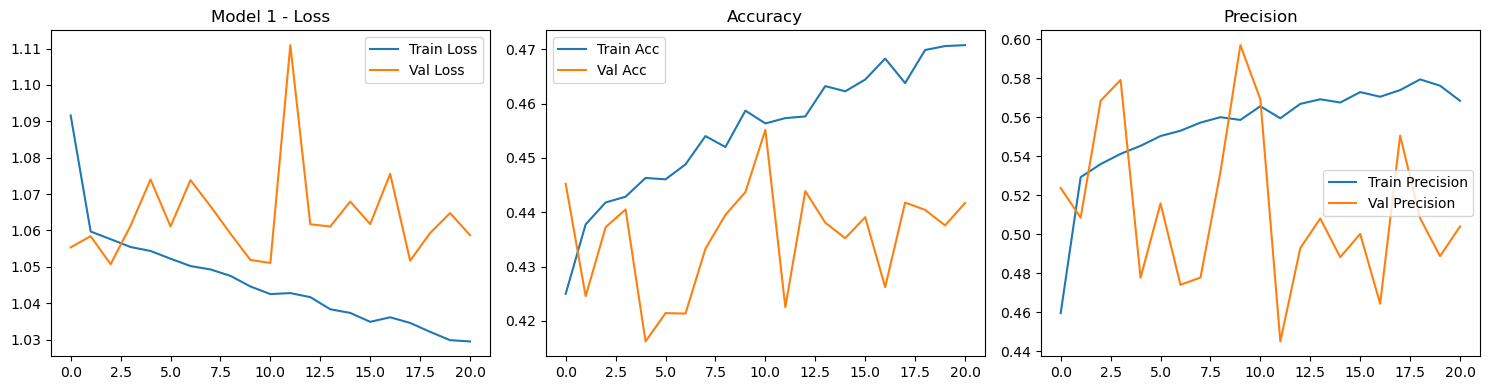

Test Loss:      1.0554
Test Accuracy:  44.40%
Test Precision: 0.5495
Test Recall:    0.0840
186/186 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.45      0.72      0.55      4858
       Happy       0.37      0.01      0.02      2453
         Sad       0.44      0.39      0.41      4565
     Neutral       0.00      0.00      0.00        13

    accuracy                           0.44     11889
   macro avg       0.31      0.28      0.25     11889
weighted avg       0.43      0.44      0.39     11889



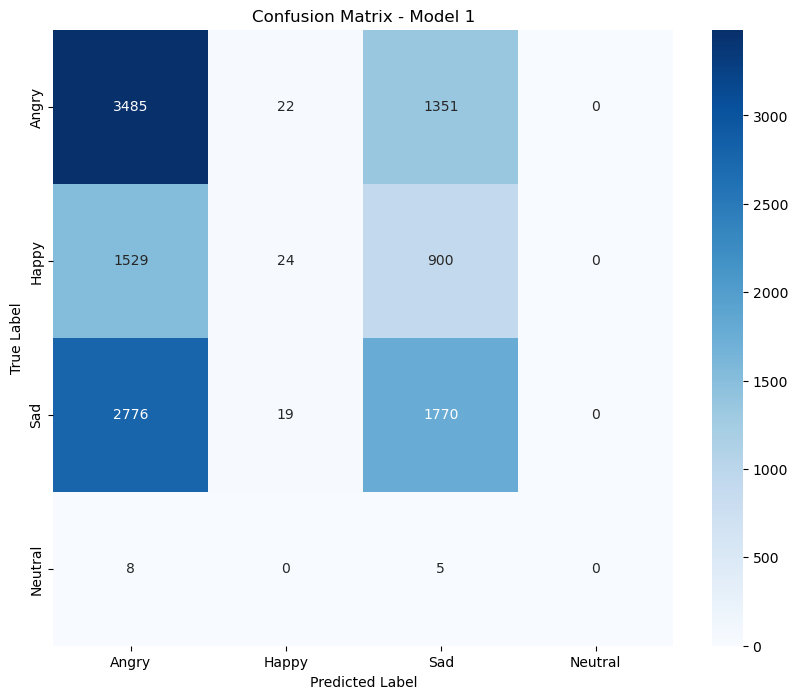


MODEL 2: ExpW_CNN_v2


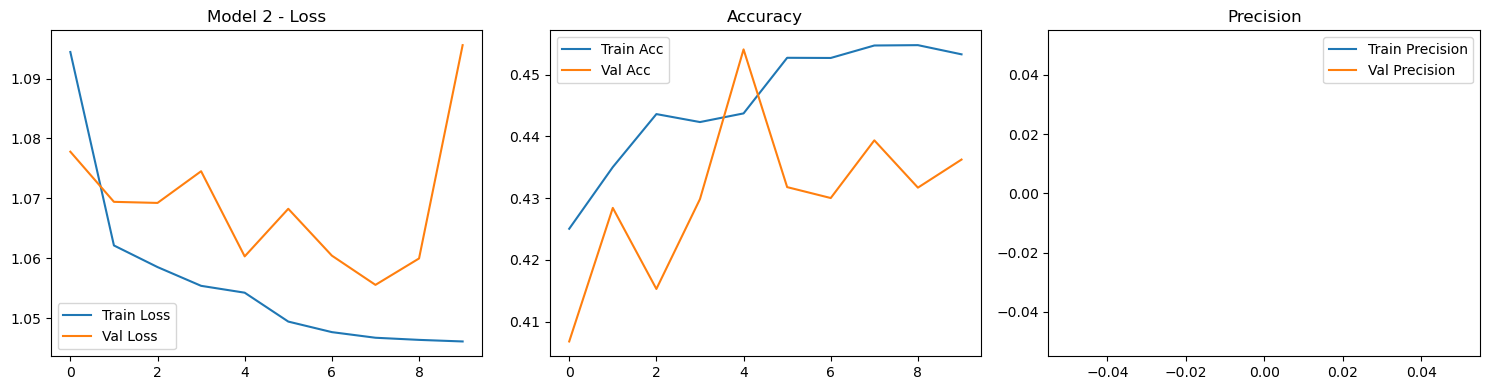

Test Loss:      1.0732
Test Accuracy:  41.13%
Test Precision: 0.4297
Test Recall:    0.0611
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.46      0.24      0.32      4858
       Happy       0.27      0.05      0.09      2453
         Sad       0.40      0.79      0.53      4565
     Neutral       0.00      0.00      0.00        13

    accuracy                           0.41     11889
   macro avg       0.28      0.27      0.23     11889
weighted avg       0.40      0.41      0.35     11889



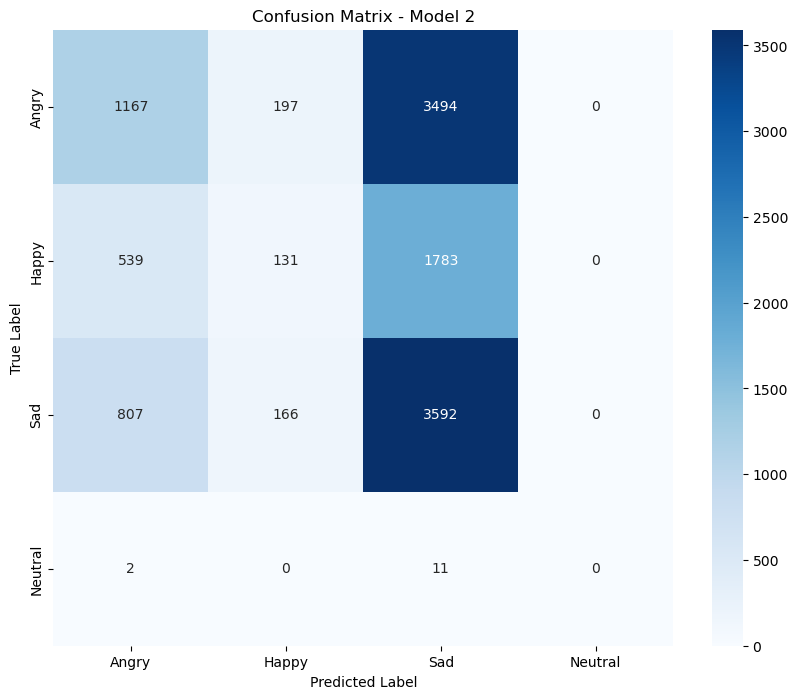


MODEL 3: ExpW_CNN_v3


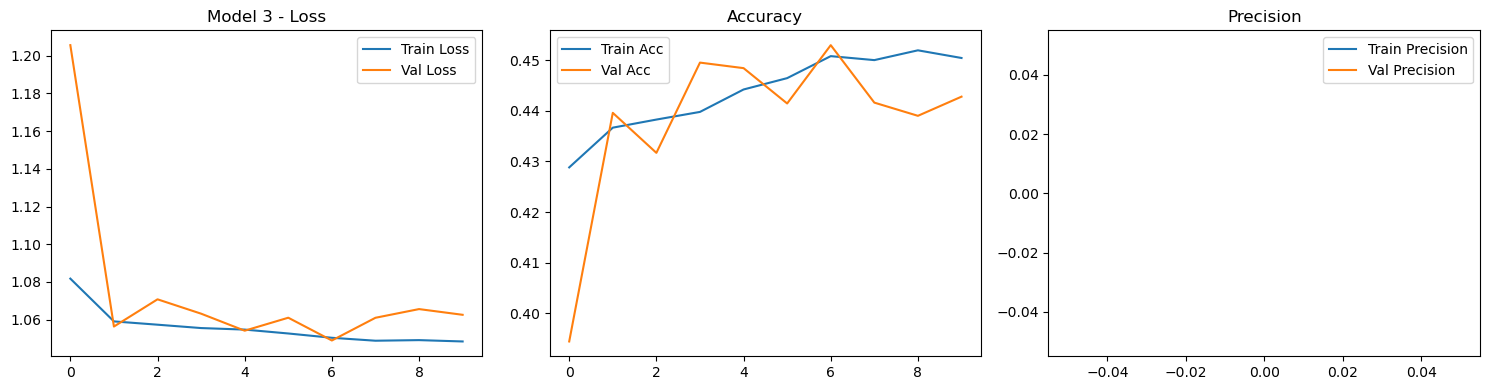

Test Loss:      1.2086
Test Accuracy:  40.23%
Test Precision: 0.4202
Test Recall:    0.1272
186/186 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.50      0.16      0.24      4858
       Happy       0.22      0.08      0.12      2453
         Sad       0.40      0.84      0.54      4565
     Neutral       0.00      0.00      0.00        13

    accuracy                           0.40     11889
   macro avg       0.28      0.27      0.22     11889
weighted avg       0.40      0.40      0.33     11889



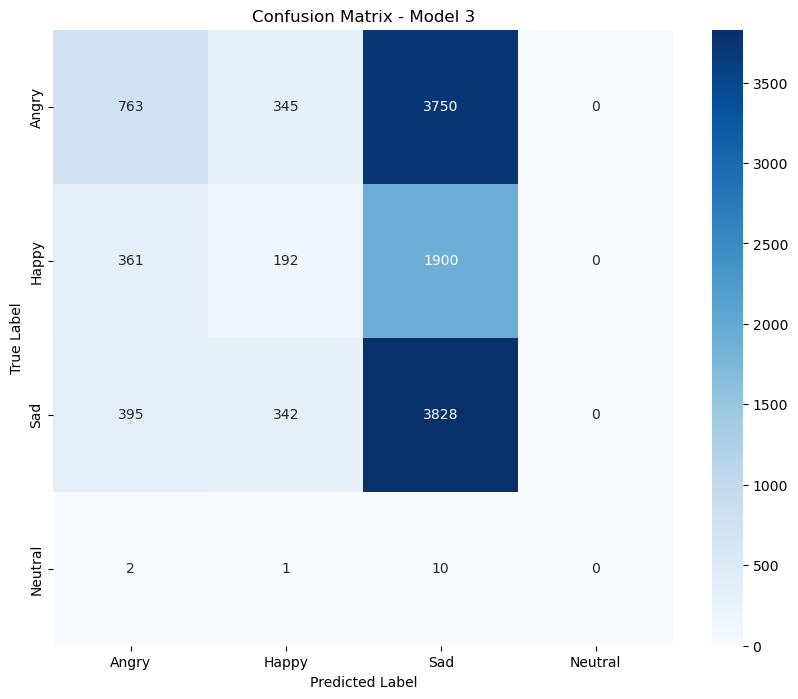


MODEL 4: ExpW_CNN_v4


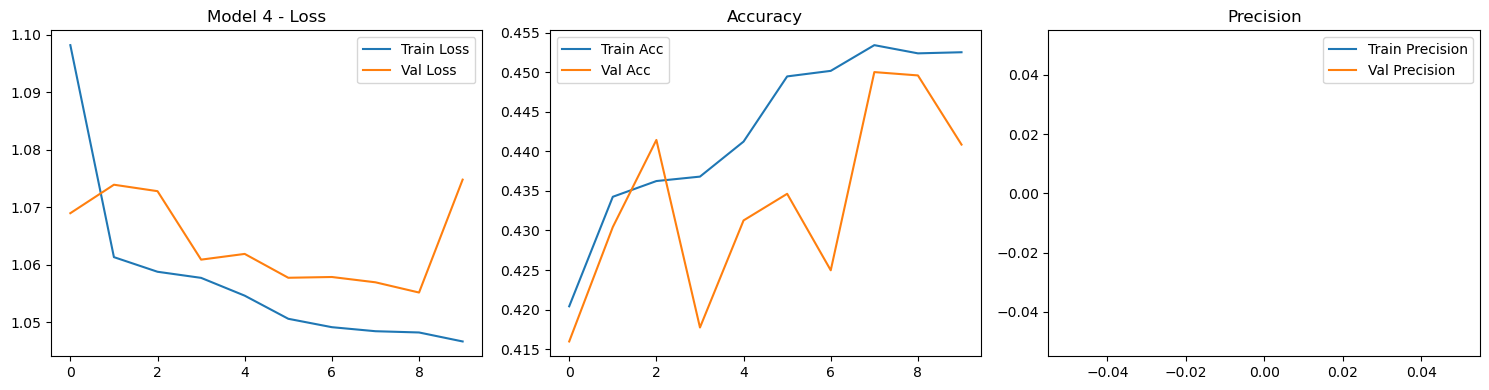

Test Loss:      1.0702
Test Accuracy:  41.63%
Test Precision: 0.6486
Test Recall:    0.0020
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.50      0.18      0.27      4858
       Happy       0.00      0.00      0.00      2453
         Sad       0.40      0.89      0.55      4565
     Neutral       0.00      0.00      0.00        13

    accuracy                           0.42     11889
   macro avg       0.22      0.27      0.20     11889
weighted avg       0.36      0.42      0.32     11889



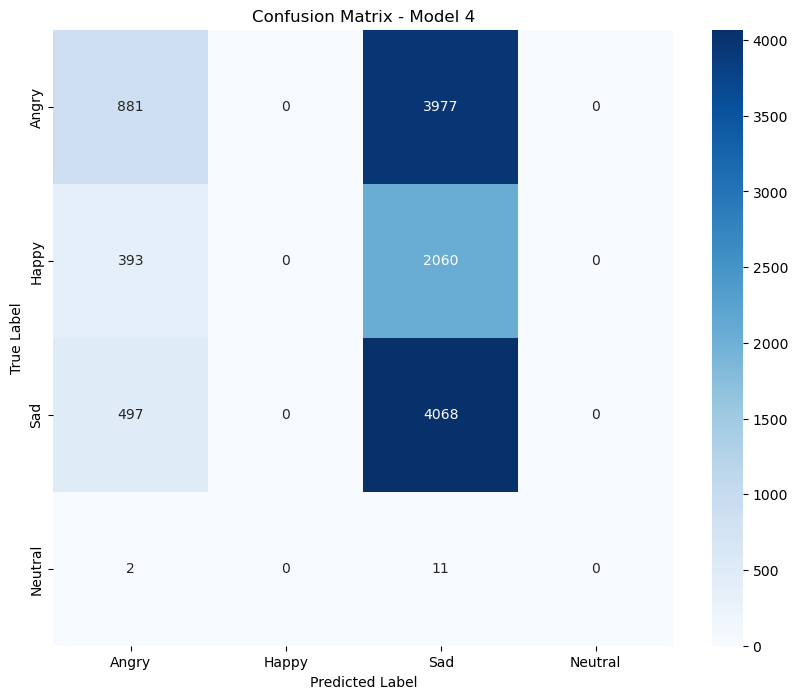

In [12]:
# ============================================================
# CELL 10: Evaluate and Visualize Results for All Models
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    axes[2].plot(history.history.get('precision', []), label='Train Precision')
    axes[2].plot(history.history.get('val_precision', []), label='Val Precision')
    axes[2].set_title('Precision')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Compare all models on test set
for idx, (model, history) in enumerate(zip(models, histories)):
    print(f"\n{'='*50}")
    print(f"MODEL {idx+1}: {model.name}")
    print('='*50)
    plot_training_history(history, f"Model {idx+1}")

    test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds, verbose=0)
    print(f"Test Loss:      {test_loss:.4f}")
    print(f"Test Accuracy:  {test_acc*100:.2f}%")
    print(f"Test Precision: {test_prec:.4f}")
    print(f"Test Recall:    {test_rec:.4f}")

    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=list(EMOTION_LABELS.values()), zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(EMOTION_LABELS.values()),
                yticklabels=list(EMOTION_LABELS.values()))
    plt.title(f'Confusion Matrix - Model {idx+1}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [13]:
# ============================================================
# CELL 11: Select Best Model for Explanations
# ============================================================
# Choose the model with the highest validation accuracy
best_model_idx = np.argmax([max(h.history['val_accuracy']) for h in histories])
best_model = models[best_model_idx]
print(f"Best model: {best_model.name} (index {best_model_idx+1}) with val_accuracy = {max(histories[best_model_idx].history['val_accuracy']):.4f}")

# Find the last convolutional layer for Grad‑CAM
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

last_conv_layer_name = find_last_conv_layer(best_model)
print(f"Using layer '{last_conv_layer_name}' for Grad‑CAM.")

Best model: ExpW_CNN_v1 (index 1) with val_accuracy = 0.4552
Using layer 'conv2d_5' for Grad‑CAM.


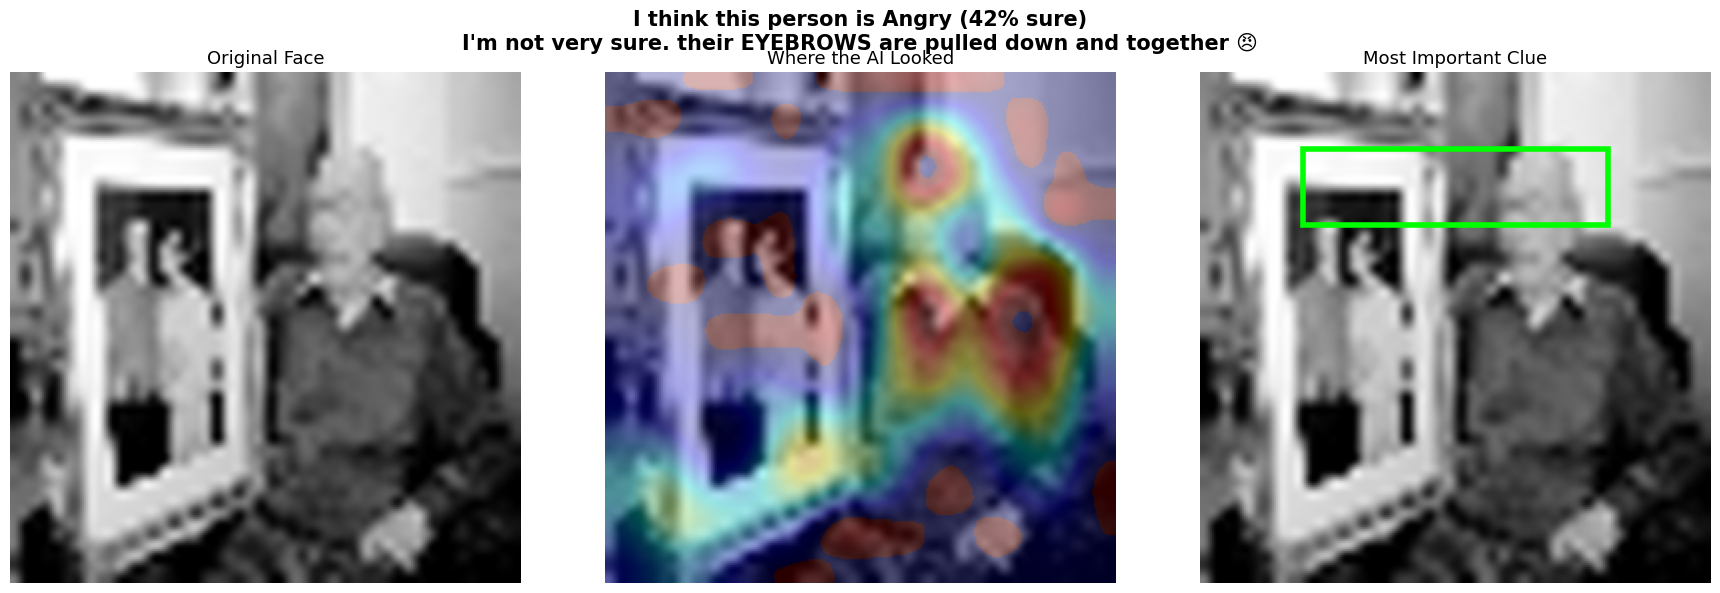


🧠 AI Explanation
Prediction: Angry
Confidence: 42%
Reason: their EYEBROWS are pulled down and together 😠


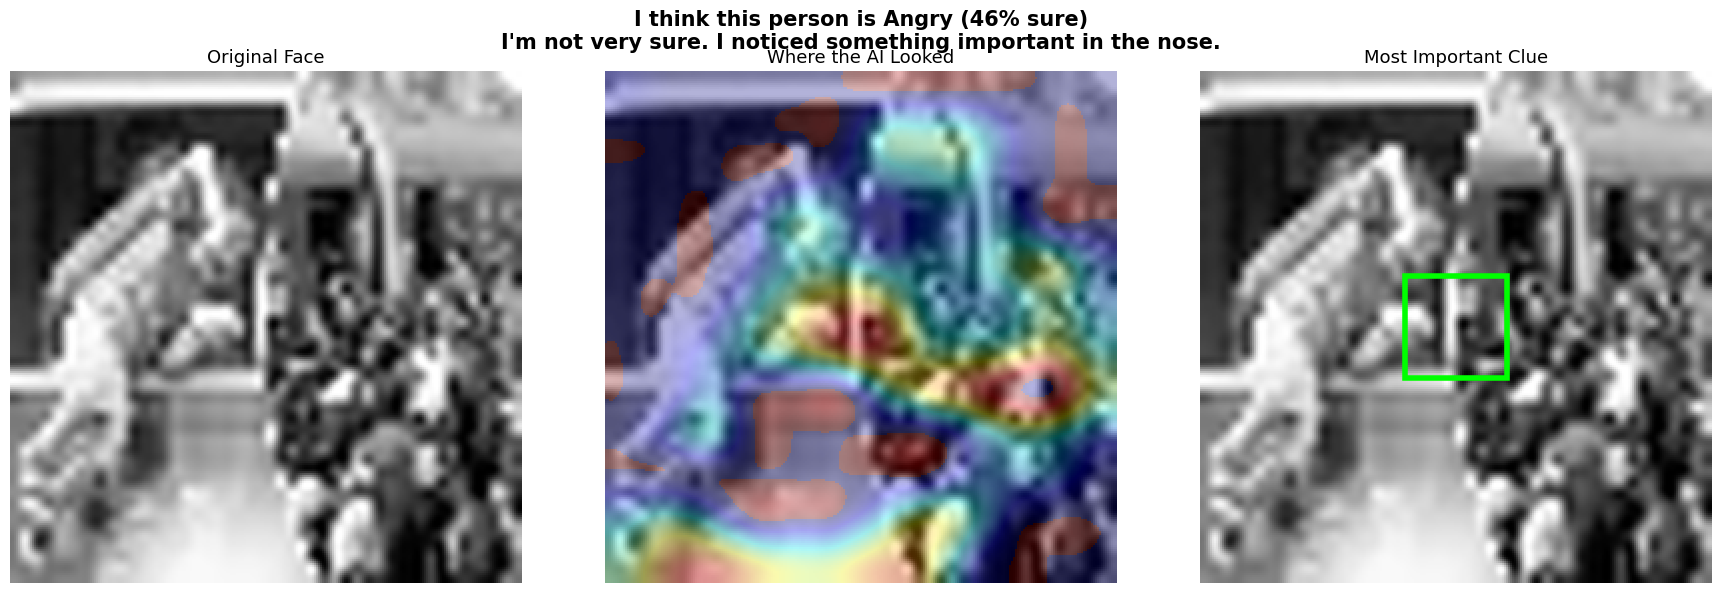


🧠 AI Explanation
Prediction: Angry
Confidence: 46%
Reason: I noticed something important in the nose.


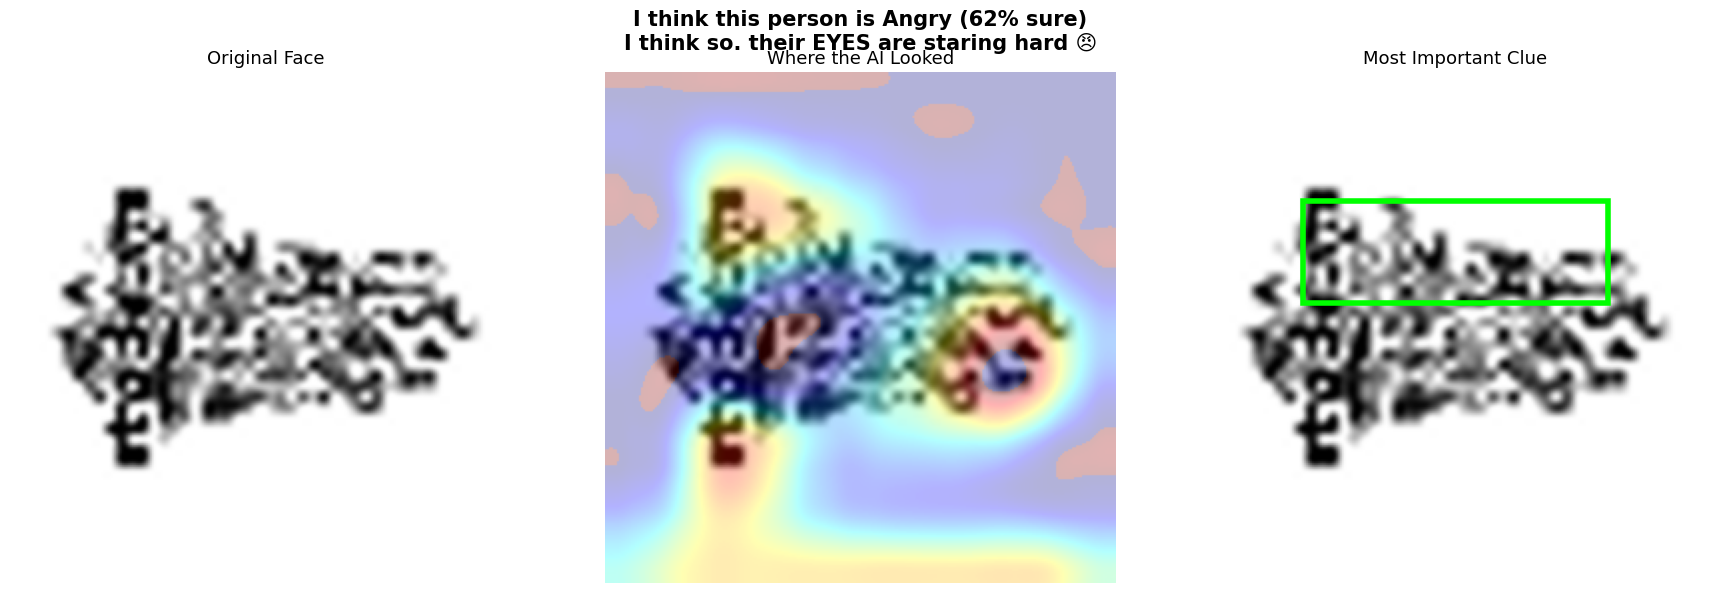


🧠 AI Explanation
Prediction: Angry
Confidence: 62%
Reason: their EYES are staring hard 😠


In [14]:
# ============================================================
# CELL 12: CHILD-FRIENDLY EXPLANATION MODULE (Improved)
# ============================================================
import matplotlib.patches as patches

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate Grad‑CAM heatmap for the predicted class."""
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap)

    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()

def get_most_important_region(heatmap):
    """Find which facial region has the highest heatmap intensity."""
    h, w = heatmap.shape
    best_region = None
    best_score = 0

    for region, (y1, y2, x1, x2) in FACE_REGIONS.items():
        y1_px, y2_px = int(y1 * h), int(y2 * h)
        x1_px, x2_px = int(x1 * w), int(x2 * w)

        y1_px, y2_px = max(0, y1_px), min(h, y2_px)
        x1_px, x2_px = max(0, x1_px), min(w, x2_px)

        if y2_px > y1_px and x2_px > x1_px:
            region_heat = heatmap[y1_px:y2_px, x1_px:x2_px]
            # Combine mean and max for robustness
            score = 0.7 * np.mean(region_heat) + 0.3 * np.max(region_heat)
            if score > best_score:
                best_score = score
                best_region = region
    return best_region, best_score

def generate_child_friendly_reason(pred_emotion, region, confidence):
    """Return a simple, child‑friendly explanation."""
    if confidence < 0.4:
        return "I'm not very sure, but I'm trying my best."
    key = (pred_emotion, region)
    if key in FRIENDLY_EXPLANATIONS:
        return FRIENDLY_EXPLANATIONS[key]
    return f"I noticed something important in the {region.lower()}."

def explain_prediction_child_friendly(image_array, model, last_conv_layer_name):
    """Generate and display a child‑friendly explanation for a single image."""
    img_array = np.expand_dims(image_array, axis=0)

    # Prediction
    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_emotion = EMOTION_LABELS[pred_idx]
    confidence = float(pred_probs[pred_idx])

    # Grad‑CAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    important_region, _ = get_most_important_region(heatmap)
    reason = generate_child_friendly_reason(pred_emotion, important_region, confidence)

    # Prepare images for display (upscale for clarity)
    DISPLAY_SIZE = 256
    img_display = (image_array.squeeze() * 255).astype(np.uint8)
    img_display = cv2.resize(img_display, (DISPLAY_SIZE, DISPLAY_SIZE),
                              interpolation=cv2.INTER_CUBIC)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)
    img_display = cv2.GaussianBlur(img_display, (3,3), 0)

    # Heatmap processing
    heatmap_resized = cv2.resize(heatmap, (DISPLAY_SIZE, DISPLAY_SIZE),
                                  interpolation=cv2.INTER_CUBIC)
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (7,7), 0)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_display, 0.7, heatmap_colored, 0.3, 0)

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_display)
    axes[0].set_title("Original Face", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title("Where the AI Looked", fontsize=13)
    axes[1].axis("off")

    axes[2].imshow(img_display)
    if important_region:
        y1, y2, x1, x2 = FACE_REGIONS[important_region]
        y1_px, y2_px = int(y1 * DISPLAY_SIZE), int(y2 * DISPLAY_SIZE)
        x1_px, x2_px = int(x1 * DISPLAY_SIZE), int(x2 * DISPLAY_SIZE)
        rect = patches.Rectangle((x1_px, y1_px), x2_px - x1_px, y2_px - y1_px,
                                 linewidth=4, edgecolor="lime", facecolor="none")
        axes[2].add_patch(rect)
    axes[2].set_title("Most Important Clue", fontsize=13)
    axes[2].axis("off")

    # Confidence tone
    if confidence > 0.75:
        certainty = "I am very sure!"
    elif confidence > 0.5:
        certainty = "I think so."
    else:
        certainty = "I'm not very sure."

    plt.suptitle(
        f"I think this person is {pred_emotion} ({confidence:.0%} sure)\n"
        f"{certainty} {reason}",
        fontsize=15, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    print("\n🧠 AI Explanation")
    print(f"Prediction: {pred_emotion}")
    print(f"Confidence: {confidence:.0%}")
    print(f"Reason: {reason}")

# Run a few examples from the test set
if last_conv_layer_name:
    num_examples = 3
    indices = np.random.choice(len(X_test), num_examples, replace=False)
    for idx in indices:
        explain_prediction_child_friendly(X_test[idx], best_model, last_conv_layer_name)
else:
    print("No convolutional layer found for Grad‑CAM.")